(2367, 11)

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       123
           1       1.00      1.00      1.00       117
           2       1.00      0.98      0.99       113
           3       1.00      1.00      1.00       118
           4       1.00      0.99      1.00       121

    accuracy                           0.99       592
   macro avg       1.00      0.99      0.99       592
weighted avg       1.00      0.99      0.99       592



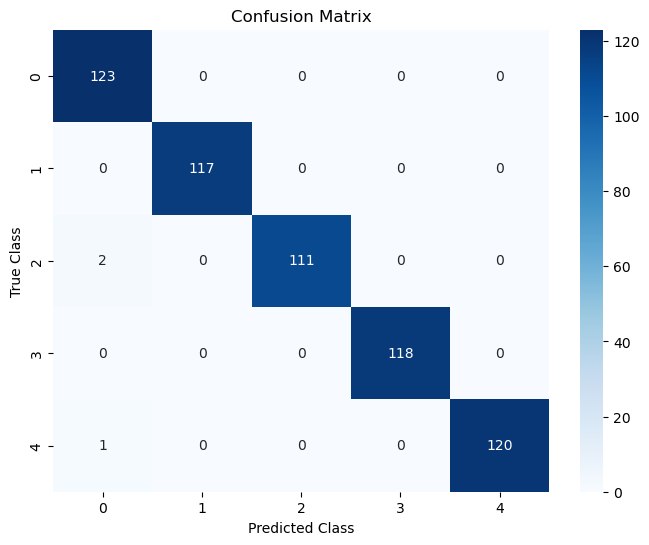

Training Accuracy: 0.9943661971830986
Test Accuracy: 0.9949324324324325


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("power_quality_fault_dataset.csv", index_col="ID")
print(df.shape)

# input features
X = df.drop(["Label","Fault_Type"], axis=1)

# output
y = df["Label"]

# encode label (safe)
le = LabelEncoder()
y = le.fit_transform(y)

# one-hot encoding
X = pd.get_dummies(X)
feature_names = X.columns

# ⚠️ SVM needs scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# training 
clf = SVC(kernel='linear', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# prediction
y_pred = clf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# accuracy
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Feature Importance:

Peak_Voltage             1.782384
RMS_Voltage              1.541726
THD                      0.898537
Duration_ms              0.107362
DWT_Energy_Level2        0.082145
DWT_Energy_Level1        0.066235
Signal_Noise_Ratio_dB    0.061330
DWT_Entropy              0.043738
Phase_A                  0.034602
Phase_C                  0.034286
Phase_B                  0.028657
dtype: float64


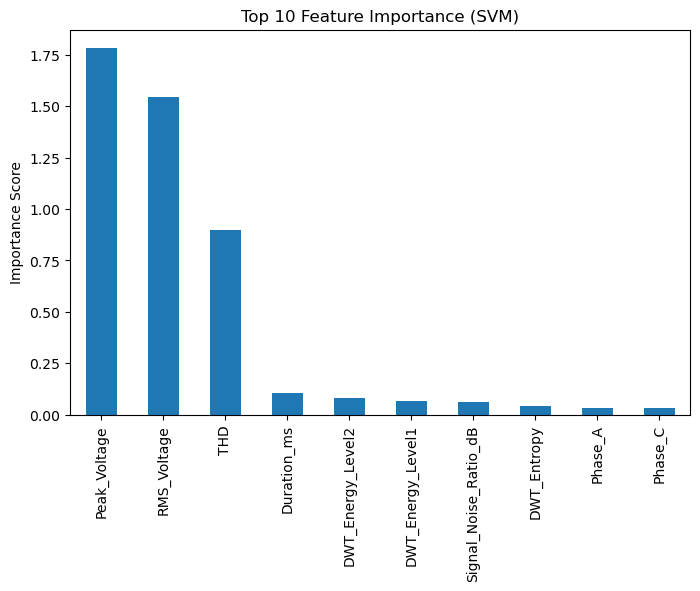

In [7]:
importance = np.abs(clf.coef_).mean(axis=0)   # average for multi-class

importance = pd.Series(importance, index=feature_names)
importance = importance.sort_values(ascending=False)

print("\nFeature Importance:\n")
print(importance)

# plot
plt.figure(figsize=(8,5))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (SVM)")
plt.ylabel("Importance Score")
plt.show()